# Soins de Ville Reimbursement Analysis
## France, 2025 (January - December)

**Data source:** [Données nationales sur les dépenses d'assurance maladie relatives aux soins de ville](https://www.assurance-maladie.ameli.fr/etudes-et-donnees/open-data-depenses-sante-soins-ville)  
**Codebook:** [2023_descriptif-variables_open-data-donnees-nationales-soins-ville](https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fwww.assurance-maladie.ameli.fr%2Fsites%2Fdefault%2Ffiles%2F2023_descriptif-variables_open-data-donnees-nationales-soins-ville.xls&wdOrigin=BROWSELINK)   
**Coverage:** Régime général, France entière, from January to December 2025  
**Tool:** DuckDB + pandas 

### Research questions
- How is pharmacy expenditure structured within soins de ville?
- Which drug categories and reimbursement codes drive the largest spend?
- Which prescriber specialties generate the most reimbursements?
- How does spending evolve across the 12 months of 2025?

In [1]:
import duckdb
duckdb.query("SET enable_progress_bar = false")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

FOLDER = r'C:\Users\Student\Downloads\Coding\Officials\SoinDeVille'

In [2]:
dfs = []
for m in range(1, 13):
    path = os.path.join(FOLDER, f'NTOT2025_{str(m).zfill(2)}.CSV')
    tmp = duckdb.query(f"""
        SELECT *
        FROM read_csv_auto(
            '{path}',
            delim=';',
            all_varchar=true,
            header=true,
            encoding='CP1252'
        )
    """).df()
    # Normalize SERIE column name
    tmp.columns = [c.upper() if c.lower() == 'serie' else c for c in tmp.columns]
    dfs.append(tmp)
    print(f"Month {m:02d}: {len(tmp):,} rows")

df = pd.concat(dfs, ignore_index=True)
df.dropna(how='all', inplace=True)

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumns: {sorted(df.columns.tolist())}")

Month 01: 350,242 rows
Month 02: 342,738 rows
Month 03: 342,758 rows
Month 04: 334,244 rows
Month 05: 339,930 rows
Month 06: 344,612 rows
Month 07: 348,980 rows
Month 08: 316,870 rows
Month 09: 348,919 rows
Month 10: 359,619 rows
Month 11: 334,128 rows
Month 12: 338,359 rows

Total rows: 4,101,399
Total columns: 30

Columns: ['PRS_FAC_TOP', 'REM_TAU', 'SERIE', 'act_coe', 'act_dnb', 'asu_nat', 'cpl_cod', 'dep_mon', 'exe_spe', 'exe_spe1', 'exe_stj1', 'l_asu_nat', 'l_cpl_cod', 'l_exe_spe', 'l_exe_spe1', 'l_exe_stj1', 'l_fac_top', 'l_pre_spe', 'l_pre_spe1', 'l_pre_stj1', 'l_prs_nat', 'l_serie', 'pre_spe', 'pre_spe1', 'pre_stj1', 'prs_nat', 'rec_mon', 'rem_date', 'rem_mon', 'sns_date']


In [3]:
df.columns = df.columns.str.lower()

numeric_cols = ['prs_fac_top', 'serie', 'prs_nat', 'rem_date', 'sns_date', 'asu_nat',
                'cpl_cod', 'rem_tau', 'pre_spe', 'pre_spe1', 'pre_stj1',
                'exe_spe', 'exe_spe1', 'exe_stj1', 'rem_mon', 'rec_mon',
                'dep_mon', 'act_dnb', 'act_coe']

for col in numeric_cols:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(
            df[col].str.replace('.', '', regex=False)
                   .str.replace(',', '.', regex=False),
            errors='coerce'
        )

print("Dtypes:")
print(df.dtypes.to_string())
print(f"\nTotal rem_mon: {df['rem_mon'].sum()/1e9:.2f}B€")

Dtypes:
prs_fac_top      int64
l_fac_top       object
l_serie         object
serie          float64
prs_nat          int64
l_prs_nat       object
rem_date         int64
sns_date         int64
asu_nat          int64
l_asu_nat       object
cpl_cod          int64
l_cpl_cod       object
rem_tau          int64
pre_spe          int64
l_pre_spe       object
pre_spe1         int64
l_pre_spe1      object
pre_stj1         int64
l_pre_stj1      object
exe_spe          int64
l_exe_spe       object
exe_spe1         int64
l_exe_spe1      object
exe_stj1         int64
l_exe_stj1      object
rem_mon        float64
rec_mon        float64
dep_mon        float64
act_dnb        float64
act_coe        float64

Total rem_mon: 127.84B€


## I. Pharmacy Expenditure

Pharmacy codes (prs_nat 3304–3423) were reviewed exhaustively against the Ameli codebook. Each code was classified into one of three categories:

- **Core:** unambiguously pharmacy (standard drugs, dispensing fees, vaccines, pharmacist acts)
- **Uncertain:** boundary cases (hospital retrocession, blood products, human-derived products)
- **Exclude:** confirmed non-pharmacy (teleconsultation tracers, miscarriage forfaits, lab PCR)

Total pharmacy spend: **31.55 B€ core / 31.71 B€ including uncertain** across 12 months 2025.

In [4]:
pharma_range = df[df['prs_nat'].between(3304, 3423)]
print(f"Total rows in range 3304-3423: {len(pharma_range):,}")
print(f"\nAll codes found:")
print(
    pharma_range.groupby(['prs_nat', 'l_prs_nat'])['rem_mon']
    .sum()
    .reset_index()
    .sort_values('rem_mon', ascending=False)
    .assign(rem_mon_m=lambda x: x['rem_mon'].div(1e6).map('{:,.2f} M€'.format))
    [['prs_nat', 'l_prs_nat', 'rem_mon_m']]
    .to_string(index=False)
)

Total rows in range 3304-3423: 447,238

All codes found:
 prs_nat                                                                                                 l_prs_nat    rem_mon_m
    3313                                                                                             PHARMACIE 65% 16,185.33 M€
    3311                                                                                            PHARMACIE 100%  6,917.30 M€
    3317                                                                             PHARMACIE HOSPITALIERE A 100%  1,798.90 M€
    3312                                                                                             PHARMACIE PH4  1,333.99 M€
    3386                                                                                               HONO DISP 7  1,323.49 M€
    3316                                                                                  MEDICAMENTS D  EXCEPTION  1,320.05 M€
    3366                                       

In [5]:
PHARMACY_CORE = [
    # Standard drugs
    3311, 3312, 3313, 3314, 3315, 3316, 3317, 3318, 3319,
    3328, 3329, 3341, 3342, 3343, 3351, 3354, 3356,
    # Compounded drugs
    3326, 3327, 3381,
    # Pharmacist fees & acts
    3304, 3305, 3310, 3322, 3325, 3346, 3348, 3349, 3350,
    3358, 3359, 3360, 3361, 3362, 3363, 3364, 3365, 3366,
    3367, 3368, 3370, 3376, 3380, 3382, 3383, 3384, 3385,
    3386, 3387, 3388, 3389, 3390, 3402, 3403, 3404, 3406,
    3408, 3410, 3415, 3416, 3417, 3418, 3419, 3420, 3423,
    # Vaccines
    3331, 3332, 3335,
]

PHARMACY_UNCERTAIN = [3330, 3352, 3353, 3355, 3411, 3413, 3414]
PHARMACY_EXCLUDE = [3308, 3309, 3337, 3338, 3369, 3405]

pharmacy_core = df[df['prs_nat'].isin(PHARMACY_CORE)].copy()
pharmacy_core['pharmacy_flag'] = 'core'

pharmacy_uncertain = df[df['prs_nat'].isin(PHARMACY_UNCERTAIN)].copy()
pharmacy_uncertain['pharmacy_flag'] = 'uncertain'

pharmacy = pd.concat([pharmacy_core, pharmacy_uncertain], ignore_index=True)

print(f"Pharmacy rows: {len(pharmacy):,}")
print(f"\nBy flag:")
print(
    pharmacy.groupby('pharmacy_flag')['rem_mon']
    .sum()
    .reset_index()
    .assign(rem_mon=lambda x: x['rem_mon'].div(1e9).map('{:,.2f} B€'.format))
    .to_string(index=False)
)
print(f"\nTotal (core + uncertain): {pharmacy['rem_mon'].sum() / 1e9:.2f} B€")
print(f"Core only:                {pharmacy_core['rem_mon'].sum() / 1e9:.2f} B€")

Pharmacy rows: 442,806

By flag:
pharmacy_flag  rem_mon
         core 31.55 B€
    uncertain  0.17 B€

Total (core + uncertain): 31.71 B€
Core only:                31.55 B€


In [6]:
category_map = {
    3311: 'Médicaments', 3312: 'Médicaments', 3313: 'Médicaments',
    3314: 'Médicaments', 3315: 'Médicaments', 3316: 'Médicaments',
    3317: 'Médicaments', 3318: 'Médicaments', 3319: 'Médicaments',
    3328: 'Médicaments', 3329: 'Médicaments', 3341: 'Médicaments',
    3351: 'Médicaments', 3354: 'Médicaments', 3356: 'Médicaments',
    3326: 'Préparations magistrales', 3327: 'Préparations magistrales',
    3342: 'Préparations magistrales', 3343: 'Préparations magistrales',
    3381: 'Préparations magistrales',
    3364: 'Honoraires dispensation', 3365: 'Honoraires dispensation',
    3366: 'Honoraires dispensation', 3380: 'Honoraires dispensation',
    3383: 'Honoraires dispensation', 3384: 'Honoraires dispensation',
    3385: 'Honoraires dispensation', 3386: 'Honoraires dispensation',
    3387: 'Honoraires dispensation', 3388: 'Honoraires dispensation',
    3389: 'Honoraires dispensation', 3390: 'Honoraires dispensation',
    3331: 'Vaccins', 3332: 'Vaccins', 3335: 'Vaccins',
    3304: 'Actes pharmacien', 3305: 'Actes pharmacien', 3310: 'Actes pharmacien',
    3322: 'Actes pharmacien', 3325: 'Actes pharmacien', 3346: 'Actes pharmacien',
    3348: 'Actes pharmacien', 3349: 'Actes pharmacien', 3350: 'Actes pharmacien',
    3358: 'Actes pharmacien', 3359: 'Actes pharmacien', 3360: 'Actes pharmacien',
    3361: 'Actes pharmacien', 3362: 'Actes pharmacien', 3363: 'Actes pharmacien',
    3367: 'Actes pharmacien', 3368: 'Actes pharmacien', 3370: 'Actes pharmacien',
    3376: 'Actes pharmacien', 3382: 'Actes pharmacien', 3402: 'Actes pharmacien',
    3403: 'Actes pharmacien', 3404: 'Actes pharmacien', 3406: 'Actes pharmacien',
    3408: 'Actes pharmacien', 3410: 'Actes pharmacien', 3415: 'Actes pharmacien',
    3416: 'Actes pharmacien', 3417: 'Actes pharmacien', 3418: 'Actes pharmacien',
    3419: 'Actes pharmacien', 3420: 'Actes pharmacien', 3423: 'Actes pharmacien',
}

pharmacy_core['category'] = pharmacy_core['prs_nat'].map(category_map)

# Verify
print(pharmacy_core.groupby('category')['rem_mon']
      .sum().div(1e9)
      .map('{:.2f} B€'.format)
      .sort_values(ascending=False))

category
Médicaments                 27.93 B€
Honoraires dispensation      2.99 B€
Actes pharmacien             0.32 B€
Vaccins                      0.16 B€
Préparations magistrales     0.15 B€
Name: rem_mon, dtype: object


In [7]:
print(
    pharmacy_core[pharmacy_core['category'] == 'Médicaments']
    .groupby(['prs_nat', 'l_prs_nat'])['rem_mon']
    .sum()
    .reset_index()
    .sort_values('rem_mon', ascending=False)
    .assign(rem_mon_m=lambda x: x['rem_mon'].div(1e6).map('{:,.2f} M€'.format))
    [['prs_nat', 'l_prs_nat', 'rem_mon_m']]
    .to_string(index=False)
)

 prs_nat                                                 l_prs_nat    rem_mon_m
    3313                                             PHARMACIE 65% 16,185.33 M€
    3311                                            PHARMACIE 100%  6,917.30 M€
    3317                             PHARMACIE HOSPITALIERE A 100%  1,798.90 M€
    3312                                             PHARMACIE PH4  1,333.99 M€
    3316                                  MEDICAMENTS D  EXCEPTION  1,320.05 M€
    3341                                             PHARMACIE 15%    177.38 M€
    3318                              PHARMACIE HOSPITALIERE A 65%    131.23 M€
    3354                MEDICAMENT AVEC AUTORISATION D'IMPORTATION     25.63 M€
    3356                        PHARMACIE HOSPITALIERE DEROGATOIRE     16.75 M€
    3329                              FORFAIT MEDICAMENT IVG VILLE      9.80 M€
    3319                                    PHARMACIE HOSPITALIERE      7.50 M€
    3351 MEDICAMENT AVEC UNE AUTORISATIO

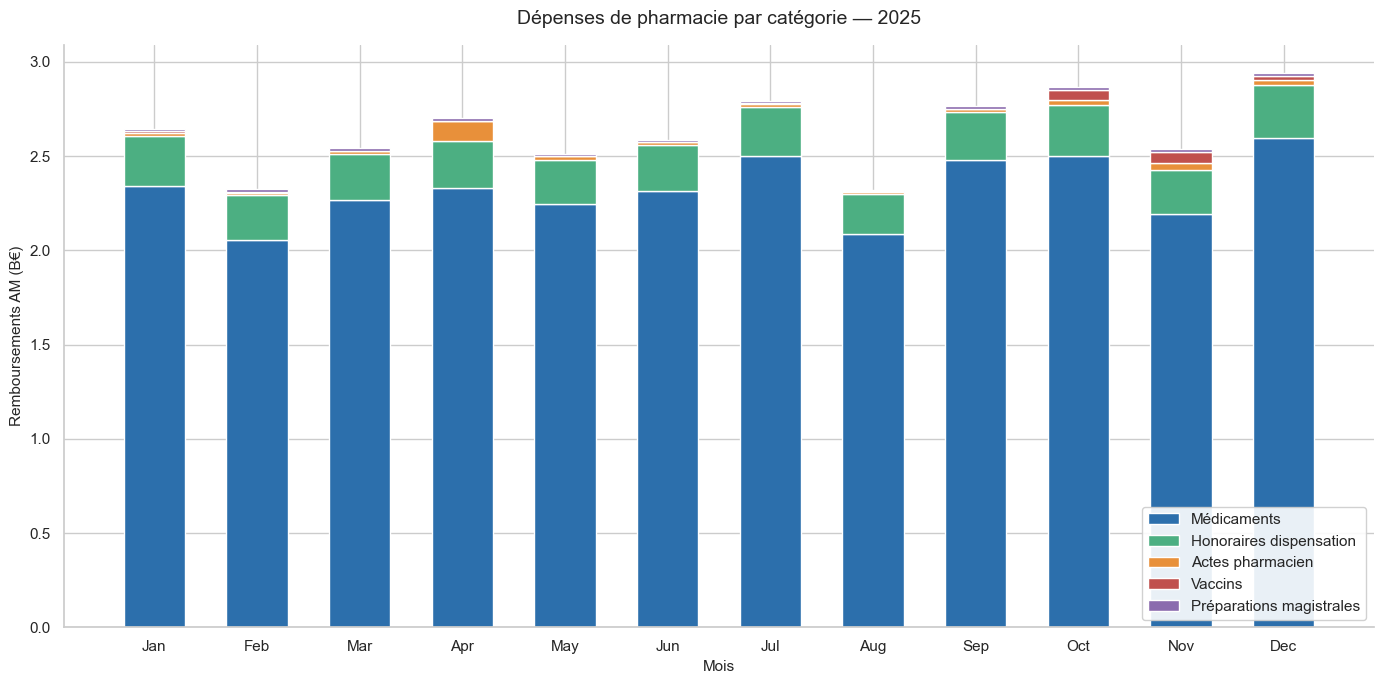

In [8]:
# Filter 2025 only
monthly_cat = (
    pharmacy_core[pharmacy_core['rem_date'].between(202501, 202512)]
    .groupby(['rem_date', 'category'])['rem_mon']
    .sum()
    .div(1e9)
    .reset_index()
    .pivot(index='rem_date', columns='category', values='rem_mon')
    .fillna(0)
)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 7))

colors = {
    'Médicaments': '#2C6FAC',
    'Honoraires dispensation': '#4CAF82',
    'Actes pharmacien': '#E8903A',
    'Vaccins': '#C0504D',
    'Préparations magistrales': '#8B6BAE',
}

bottom = pd.Series([0] * len(monthly_cat), index=monthly_cat.index)

for cat in ['Médicaments', 'Honoraires dispensation', 'Actes pharmacien', 'Vaccins', 'Préparations magistrales']:
    ax.bar(range(len(monthly_cat)), monthly_cat[cat],
           bottom=bottom.values, label=cat, color=colors[cat], width=0.6)
    bottom += monthly_cat[cat]

ax.set_title('Dépenses de pharmacie par catégorie — 2025', fontsize=14, pad=15)
ax.set_xlabel('Mois', fontsize=11)
ax.set_ylabel('Remboursements AM (B€)', fontsize=11)
ax.set_xticks(range(len(monthly_cat)))
ax.set_xticklabels(month_labels, rotation=0)
ax.legend(loc='lower right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

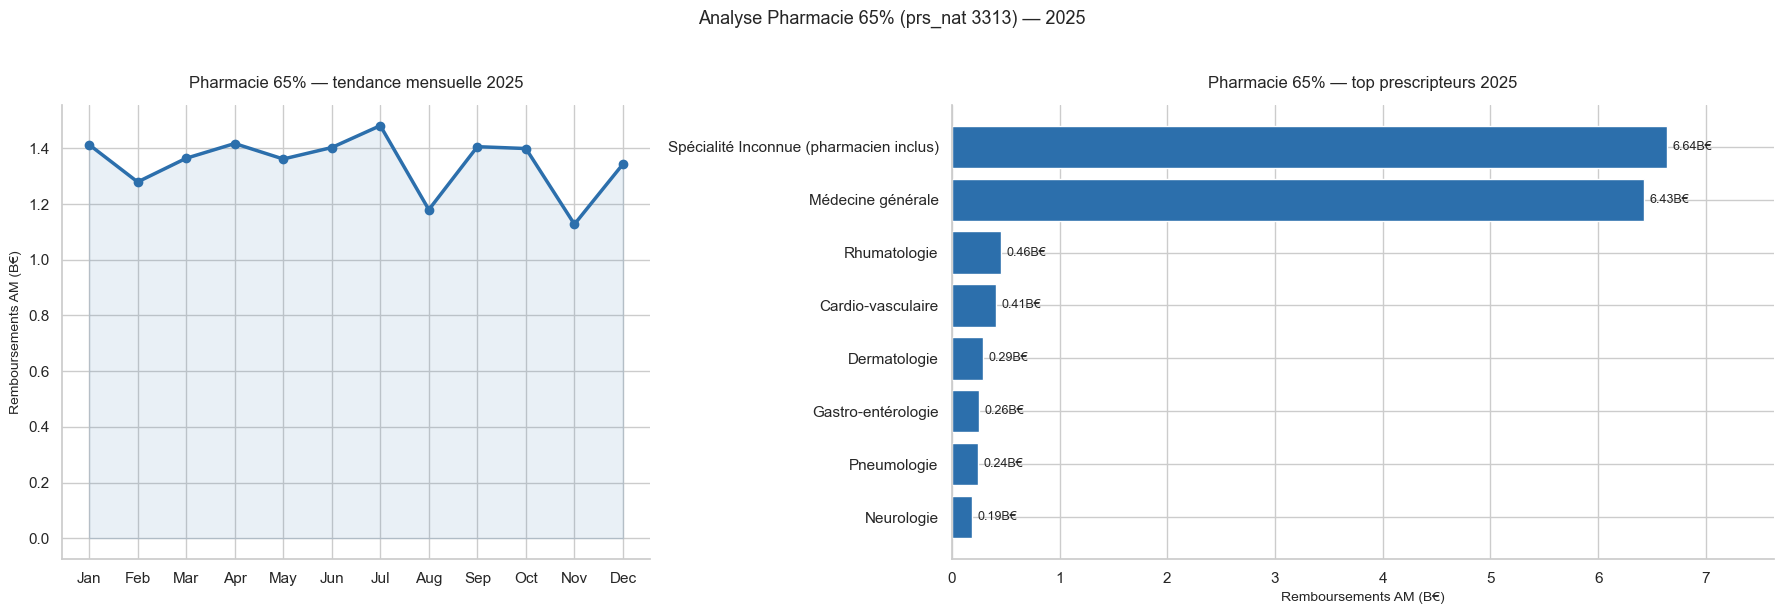

In [9]:
pharma_65 = df[df['prs_nat'] == 3313].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1.4]})

# --- Chart 1: Monthly trend ---
monthly_65 = (
    pharma_65[pharma_65['rem_date'].between(202501, 202512)]
    .groupby('rem_date')['rem_mon']
    .sum()
    .div(1e9)
)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

ax1.plot(range(12), monthly_65.values, color='#2C6FAC', linewidth=2.5, marker='o', markersize=6)
ax1.fill_between(range(12), monthly_65.values, alpha=0.1, color='#2C6FAC')
ax1.set_title('Pharmacie 65% — tendance mensuelle 2025', fontsize=12, pad=12)
ax1.set_ylabel('Remboursements AM (B€)', fontsize=10)
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels, rotation=0)
sns.despine(ax=ax1)

# --- Chart 2: Top prescribers with value labels ---
top_pre = (
    pharma_65
    .groupby('pre_spe')['rem_mon']
    .sum()
    .reset_index()
    .sort_values('rem_mon', ascending=False)
    .head(8)
)

label_map = {
    99: 'Spécialité Inconnue (pharmacien inclus)',
    1: 'Médecine générale',
    14: 'Rhumatologie',
    3: 'Cardio-vasculaire',
    5: 'Dermatologie',
    8: 'Gastro-entérologie',
    13: 'Pneumologie',
    32: 'Neurologie',
}
top_pre['label'] = top_pre['pre_spe'].map(label_map)
top_pre['rem_mon_bn'] = top_pre['rem_mon'] / 1e9

bars = ax2.barh(top_pre['label'][::-1], top_pre['rem_mon_bn'][::-1], color='#2C6FAC')

# Add value labels
for bar, val in zip(bars, top_pre['rem_mon_bn'][::-1]):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}B€', va='center', fontsize=9)

ax2.set_title('Pharmacie 65% — top prescripteurs 2025', fontsize=12, pad=12)
ax2.set_xlabel('Remboursements AM (B€)', fontsize=10)
ax2.set_xlim(0, top_pre['rem_mon_bn'].max() * 1.15)
sns.despine(ax=ax2)

plt.suptitle('Analyse Pharmacie 65% (prs_nat 3313) — 2025', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

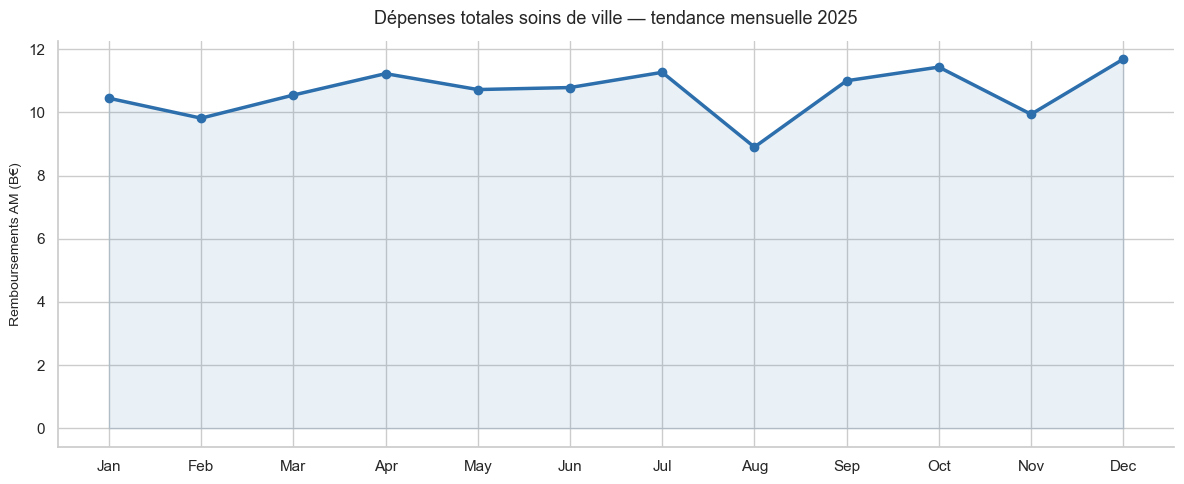

In [10]:
# Overall monthly trend
monthly_total = (
    df[df['rem_date'].between(202501, 202512)]
    .groupby('rem_date')['rem_mon']
    .sum()
    .div(1e9)
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(12), monthly_total.values, color='#2C6FAC', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(range(12), monthly_total.values, alpha=0.1, color='#2C6FAC')
ax.set_title('Dépenses totales soins de ville — tendance mensuelle 2025', fontsize=13, pad=12)
ax.set_ylabel('Remboursements AM (B€)', fontsize=10)
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
sns.despine()
plt.tight_layout()
plt.show()

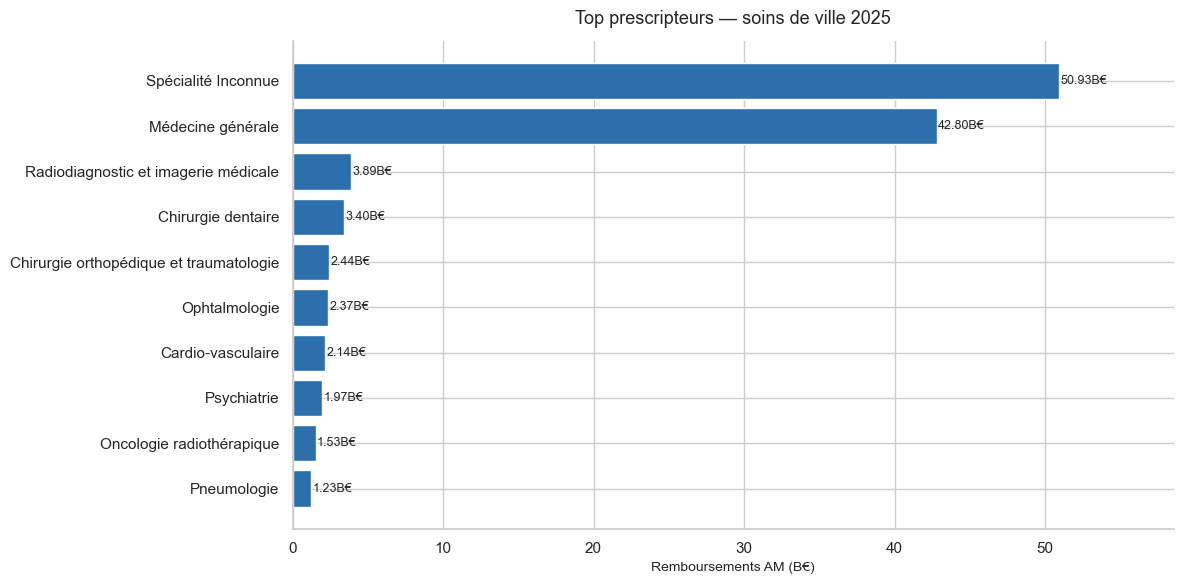

In [11]:
# Top prescriber specialties overall
fig, ax = plt.subplots(figsize=(12, 6))

top_pre_all = (
    df[df['pre_spe'] != 0]
    .groupby('pre_spe')['rem_mon']
    .sum()
    .reset_index()
    .merge(df[['pre_spe','l_pre_spe']].drop_duplicates('pre_spe'), on='pre_spe')
    .sort_values('rem_mon', ascending=False)
    .head(10)
)
top_pre_all['label'] = top_pre_all['pre_spe'].map({
    99: 'Spécialité Inconnue',
    1: 'Médecine générale',
    24: 'Infirmier',
    26: 'Masseur-kinésithérapeute',
    14: 'Rhumatologie',
    3: 'Cardio-vasculaire',
    33: 'Psychiatrie',
    5: 'Dermatologie',
    12: 'Pédiatrie',
    32: 'Neurologie',
}).fillna(top_pre_all['l_pre_spe'].str.split('-').str[1:].str.join('-').str.strip())
top_pre_all['rem_mon_bn'] = top_pre_all['rem_mon'] / 1e9

bars = ax.barh(top_pre_all['label'][::-1], top_pre_all['rem_mon_bn'][::-1], color='#2C6FAC')
for bar, val in zip(bars, top_pre_all['rem_mon_bn'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}B€', va='center', fontsize=9)

ax.set_title('Top prescripteurs — soins de ville 2025', fontsize=13, pad=12)
ax.set_xlabel('Remboursements AM (B€)', fontsize=10)
ax.set_xlim(0, top_pre_all['rem_mon_bn'].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

## Conclusions

This analysis covers 4,101,399 reimbursement rows across 12 months of 2025, representing **127.84 B€** in total soins de ville reimbursements from AM.

### Key findings

- **Pharmacy accounts for 31.55 B€** (approximately 25% of total soins de ville spend). Médicaments alone represent 27.93 B€, of which Pharmacie 65% (prs_nat 3313) accounts for 16.19 B€, by far the single largest expenditure code. Dispensing fees (honoraires de dispensation), introduced in 2015, add a further 2.99 B€.

- **Médecine générale is the dominant traceable prescriber** at 42.80 B€. Code 99 (Spécialité Inconnue, pharmacien inclus) represents 50.93 B€ (~40% of total), reflecting the structural limits of prescriber traceability in the SNDS for non-physician-initiated acts.

- **Radiodiagnostic appears as the third largest prescriber** at 3.89 B€, but this figure primarily reflects self-attributed technical acts (imagerie CCAM, forfaits IRMN/scanner) in SNDS coding rather than traditional prescribing behaviour.

- **August shows a consistent seasonal dip** across all categories (8.9 B€ vs ~10.8 B€ monthly average), consistent with reduced medical activity during summer.

### Limitations

- **Prescriber code 99 (Spécialité Inconnue)** covers ~40% of reimbursements. It aggregates unidentifiable prescribers, pharmacist-initiated acts (vaccinations, TROD, bilans médication), and non-physician prescriptions (nurses, midwives). The relative weight of each sub-group within code 99 cannot be determined from this dataset alone.
- **Mixed file encodings** (UTF-8 and CP1252) across the 12 monthly files were resolved by standardising to CP1252 at read time.
- **Molecule-level analysis** requires Open Medic data (see Notebook 3).